In [1]:
import pymc as pm, polars as pl, arviz as az, numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import legend

from utils import extract_quantile_columns, standardize_columns, plot_trace

In [2]:
df = pl.read_csv("../../Rethinking_2/End_of_chapter_problems/data/chimpanzees.csv", separator=";").drop("recipient", "trial").rename({"condition":"partner_present"})

In [3]:
df = df.with_columns(
    treatment=pl.col("prosoc_left")+2*pl.col("partner_present"),
    actor=pl.col("actor")-1,
    block=pl.col("block")-1
)
df = df.group_by("actor", "treatment", "block").agg(N=pl.len(),
                                               pulled_left=pl.sum("pulled_left"))

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_bar, sigma_alpha, z_actor, sigma_gamma, z_gamma, beta_treatment]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 9 seconds.
Sampling: [beta_treatment, pulled_left, z_actor, z_gamma]


Output()

Output()

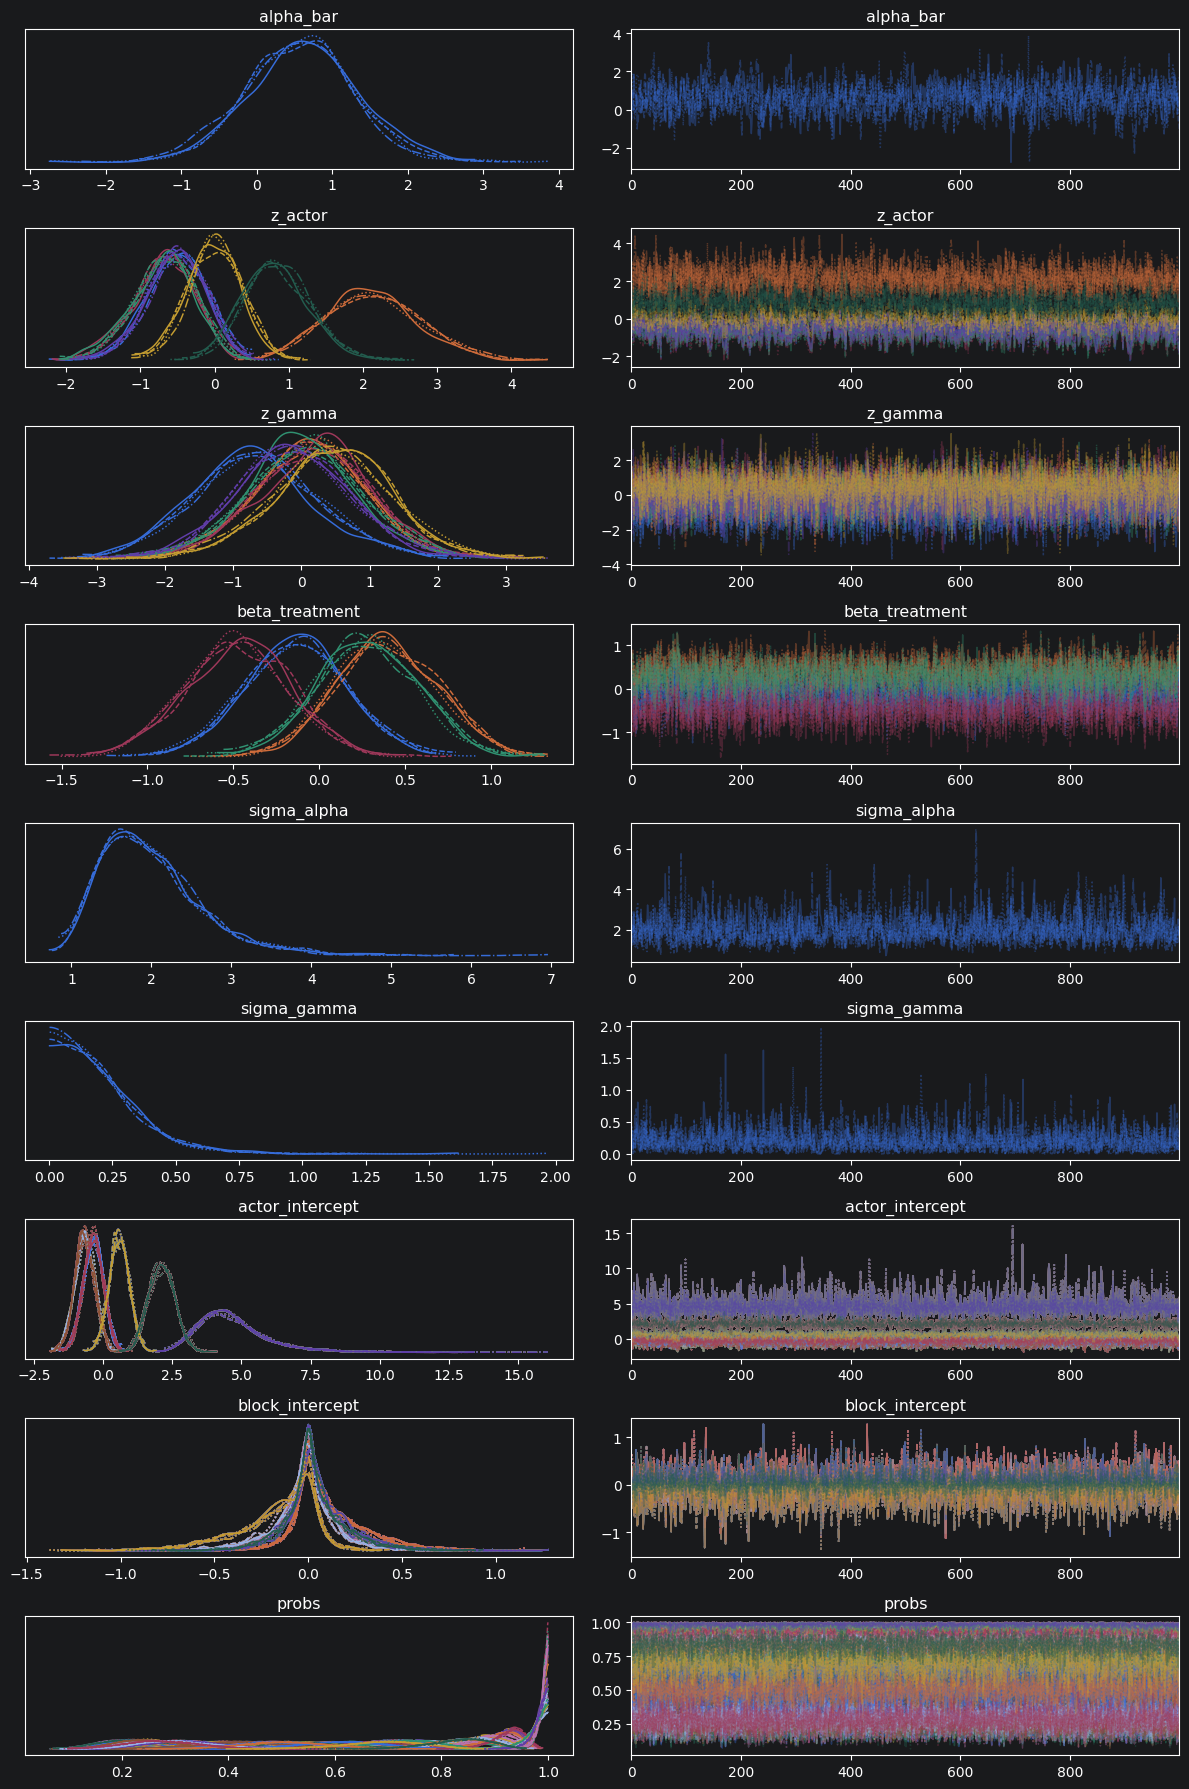

In [5]:
with pm.Model(coords={
    "treatment": df["treatment"].unique(),
    "actor": df["actor"].unique(),
    "block": df["block"].unique(),
}) as base_model:
    # data definition
    actor = pm.Data("actor", df["actor"].to_numpy())
    treatment = pm.Data("treatment", df["treatment"].to_numpy())
    block = pm.Data("block", df["block"].to_numpy())

    # actor priors
    alpha_bar = pm.Normal("alpha_bar", 0, 1.5)
    sigma_actor = pm.Exponential("sigma_alpha", 1)
    z_actor = pm.Normal("z_actor", 0, 1, dims="actor")
    actor_intercept = pm.Deterministic("actor_intercept", alpha_bar + z_actor[actor] * sigma_actor)

    sigma_gamma = pm.Exponential("sigma_gamma", 1)
    z_gamma = pm.Normal("z_gamma", 0, 1, dims="block")
    block_intercept = pm.Deterministic("block_intercept", z_gamma[block]*sigma_gamma)

    beta_treatment = pm.Normal("beta_treatment", 0, 0.5, dims="treatment")

    logit = actor_intercept + block_intercept + beta_treatment[treatment]
    probs = pm.Deterministic("probs", pm.invlogit(logit))

    # fit to observed
    pulled_left = pm.Binomial("pulled_left", n=df["N"].to_numpy(), p=probs, observed=df["pulled_left"].to_numpy())

    # sample å
    posterior_first = pm.sample(chains=4, tune=2000, target_accept=0.99, progressbar=True)
    posterior_predictive = pm.sample_posterior_predictive(posterior_first)
    pm.compute_log_likelihood(posterior_first)

plot_trace(posterior_first)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_bar, sigma_alpha, z_actor, gamma_bar, sigma_gamma, z_gamma, beta_treatment]


Output()

Sampling 4 chains for 2_000 tune and 1_000 draw iterations (8_000 + 4_000 draws total) took 16 seconds.
Sampling: [beta_treatment, pulled_left, z_actor, z_gamma]


Output()

Output()

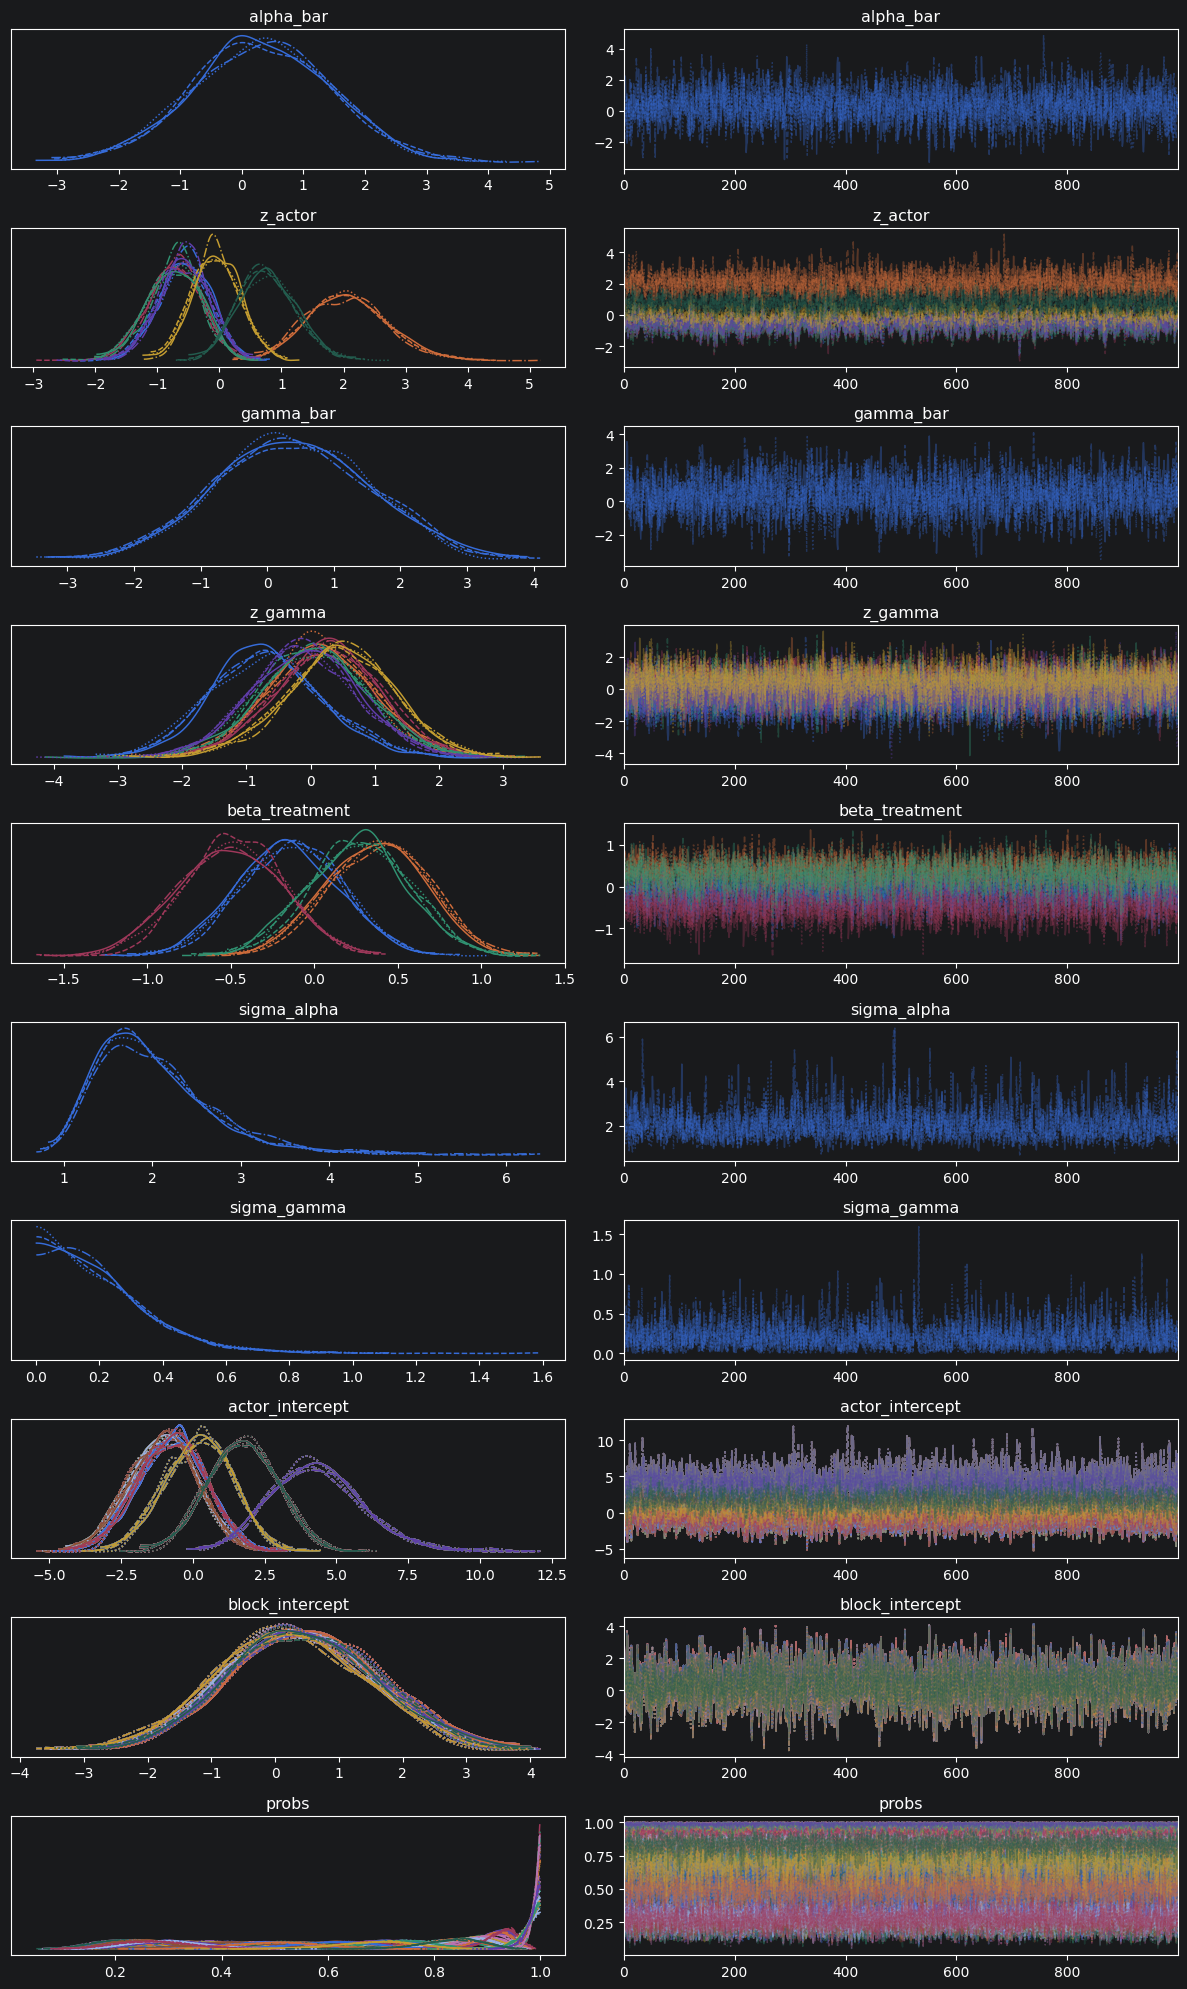

In [6]:
with pm.Model(coords={
    "treatment": df["treatment"].unique(),
    "actor": df["actor"].unique(),
    "block": df["block"].unique(),
}) as base_model:
    # data definition
    actor = pm.Data("actor", df["actor"].to_numpy())
    treatment = pm.Data("treatment", df["treatment"].to_numpy())
    block = pm.Data("block", df["block"].to_numpy())

    # actor priors
    alpha_bar = pm.Normal("alpha_bar", 0, 1.5)
    sigma_actor = pm.Exponential("sigma_alpha", 1)
    z_actor = pm.Normal("z_actor", 0, 1, dims="actor")
    actor_intercept = pm.Deterministic("actor_intercept", alpha_bar + z_actor[actor] * sigma_actor)

    gamma_bar = pm.Normal("gamma_bar", 0, 1.5)
    sigma_gamma = pm.Exponential("sigma_gamma", 1)
    z_gamma = pm.Normal("z_gamma", 0, 1, dims="block")
    block_intercept = pm.Deterministic("block_intercept", gamma_bar + z_gamma[block]*sigma_gamma)

    beta_treatment = pm.Normal("beta_treatment", 0, 0.5, dims="treatment")

    logit = actor_intercept + block_intercept + beta_treatment[treatment]
    probs = pm.Deterministic("probs", pm.invlogit(logit))

    # fit to observed
    pulled_left = pm.Binomial("pulled_left", n=df["N"].to_numpy(), p=probs, observed=df["pulled_left"].to_numpy())

    # sample å
    posterior_second = pm.sample(chains=4, tune=2000, target_accept=0.99, progressbar=True)
    posterior_predictive = pm.sample_posterior_predictive(posterior_second)
    pm.compute_log_likelihood(posterior_second)

plot_trace(posterior_second)

In [9]:
comparison = az.compare({"first": posterior_first,
                         "second": posterior_second}, scale="deviance")
comparison

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
second,0,338.216834,11.246823,0.000000,1.0,18.952015,0.000000,False,deviance
first,1,338.227667,11.163241,0.010832,0.0,18.973337,0.168122,False,deviance


<Axes: title={'center': 'Model comparison\nlower is better'}, xlabel='elpd_loo (deviance)', ylabel='ranked models'>

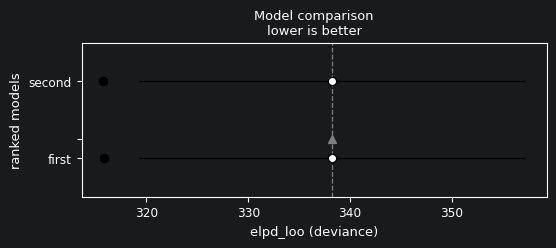

In [8]:
az.plot_compare(comparison, plot_ic_diff=True, insample_dev=True)